In [1]:
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
def convert_str_to_date(date, sep=None, datetime=False):
    if sep:
        date = date.split(sep)
    if datetime:
        dtime = dt.datetime.fromisoformat(date)
    else:
        dtime = dt.date(int(date[0]),int(date[1]),int(date[2]))

    return dtime

In [3]:
pwd

'/home/nvbemmel/ADACS_keck_project/image_analysis'

In [4]:
pcs = pd.read_csv('../PCS_InitialConditions_Highlighted.csv')
pcs['Date'] = [convert_str_to_date(x,'-') for x in pcs['Date']]
pcs

,Date,Highlighted,Instrument,Snap,Telfocus,XTilt,YTilt,CA,CE,Comments,Elevation,ID#
0,2025-07-09,1,PCS,15482,-1.962,-331.9000,219.5000,-11.0,-3.2,snap and secondary from CPH30 - JP,70.15,4945
1,2025-06-15,1,PCS,15389,-2.000,-317.8000,216.4000,-1.6,-10.9,"CPH 30, new acs snap and secondary params -TR",70.55,4926
2,2025-05-14,1,PCS,15179,-1.977,-301.3000,203.8000,-1.8,-13.2,after CPH30 PCS tests from Mitch and Gary. Tel...,63.92,4901
3,2025-04-22,1,PCS,15111,-1.990,-312.6000,195.7000,8.4,-17.0,CPH30 after Pier Repair 8-) MW,66.39,4890
4,2025-02-10,1,PCS,15003,-1.923,-336.7000,208.5000,-7.4,-7.7,PCS test 1065 CPH30,76.25,4866
...,...,...,...,...,...,...,...,...,...,...,...,...
390,1994-11-20,0,PCS,1798,13.400,0.1611,-0.1575,37.0,-45.0,T512 (Phasing 1000) & restack,NaN,1820
391,1994-11-14,0,PCS,1701,13.520,0.1525,-0.1459,27.0,-36.0,T513 on PCS,NaN,1821
392,1994-10-21,0,PCS,1598,13.350,0.1675,-0.1537,0.0,0.0,T357 (?) op align after phasing,NaN,1823
393,1994-10-18,0,PCS,1565,13.410,0.1603,-0.1558,34.0,-42.0,T513 op align,NaN,1824


In [5]:
mira = pd.read_csv('../MIRA_image_dates.csv')
mira['date'] = [convert_str_to_date(x,'-', datetime=False) for x in mira['date']]
mira['datetime'] = [convert_str_to_date(x, datetime=True) for x in mira['datetime']]
mira = mira.replace('DEIMOS: real science mosaic CCD subsystem with PowerPC in VME crate', 'DEIMOS')
mira = mira.drop(labels='Unnamed: 0', axis=1)
mira = mira.sort_values(by='telescope')
mira

,date,datetime,date_obs,telescope,instrument,image_name
426,2025-10-31,2025-10-31 10:15:57,NaN,k1,MOSFIRE,2557_9003.fits
563,2025-07-23,2025-07-23 05:39:12,NaN,k1,MOSFIRE,2467_9003.fits
564,2025-06-15,2025-06-15 06:09:09,NaN,k1,MOSFIRE,2410_9003.fits
565,2025-06-09,2025-06-09 10:38:02,NaN,k1,MOSFIRE,2405_9001.fits
566,2025-06-15,2025-06-15 05:55:31,NaN,k1,MOSFIRE,2408_9000.fits
...,...,...,...,...,...,...
106,2025-10-24,2025-10-24 13:33:46,2025-10-24T13:33:46,k2,DEIMOS,3146_0000.fits
105,2025-10-22,2025-10-22 07:36:38,2025-10-22T07:36:38,k2,DEIMOS,3141_0000.fits
104,2025-10-22,2025-10-22 04:30:09,2025-10-22T04:30:10,k2,DEIMOS,3137_0000.fits
102,2025-10-23,2025-10-23 08:48:16,2025-10-23T08:48:16,k2,DEIMOS,3143_0000.fits


In [6]:
pcs_datesubset = pcs[pcs['Date'] > min(mira['date'])]
pcs_datesubset

,Date,Highlighted,Instrument,Snap,Telfocus,XTilt,YTilt,CA,CE,Comments,Elevation,ID#
0,2025-07-09,1,PCS,15482,-1.962,-331.9,219.5,-11.0,-3.2,snap and secondary from CPH30 - JP,70.15,4945
1,2025-06-15,1,PCS,15389,-2.000,-317.8,216.4,-1.6,-10.9,"CPH 30, new acs snap and secondary params -TR",70.55,4926
2,2025-05-14,1,PCS,15179,-1.977,-301.3,203.8,-1.8,-13.2,after CPH30 PCS tests from Mitch and Gary. Tel...,63.92,4901
3,2025-04-22,1,PCS,15111,-1.990,-312.6,195.7,8.4,-17.0,CPH30 after Pier Repair 8-) MW,66.39,4890
4,2025-02-10,1,PCS,15003,-1.923,-336.7,208.5,-7.4,-7.7,PCS test 1065 CPH30,76.25,4866


In [7]:
keck_colour = {'k1':'red', 'k2':'blue'}

keck_colour[mira['telescope'][0]]

'blue'

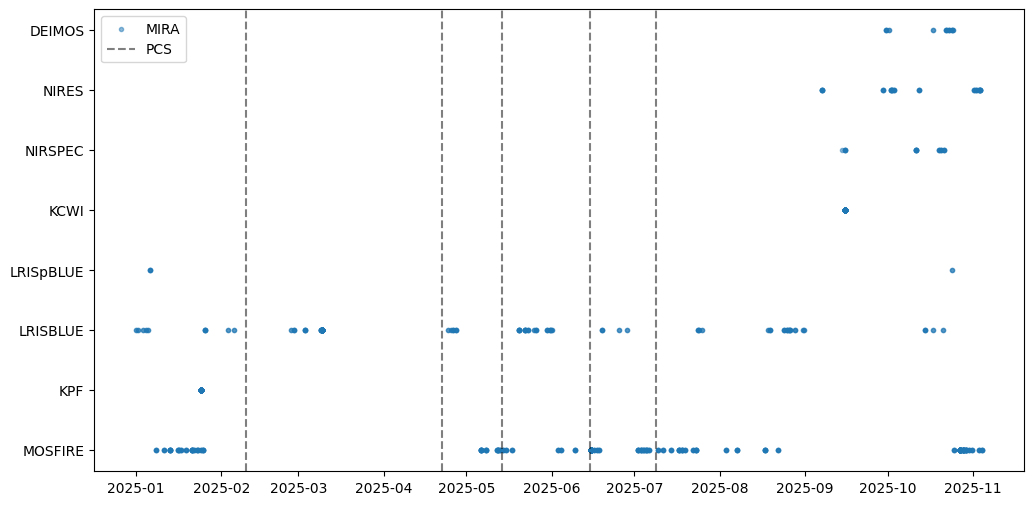

In [8]:
keck_colour = {'k1':'red', 'k2':'blue'}

fig = plt.figure(figsize=(12, 6))
plt.scatter(mira['datetime'], mira['instrument'], marker='.', alpha=0.5)

for i in np.arange(len(pcs_datesubset)):
    plt.axvline(pcs_datesubset['Date'].iloc[i], c='k',ls='--', alpha=0.5)

plt.legend(['MIRA', 'PCS'])

In [ ]:
mira = mira.sort_values(by='date')

for i in np.arange(len(pcs_datesubset)):
    if i < np.max(len(pcs_datesubset)-1):
        print('='*60)
        print(f"           In PCS window {pcs_datesubset['Date'].iloc[i+1]} to {pcs_datesubset['Date'].iloc[i]}:\n")

        mira_window = mira[(mira['date'] >= pcs_datesubset['Date'].iloc[i+1]) & (mira['date'] < pcs_datesubset['Date'].iloc[i])]
        for inst in mira_window['instrument'].unique():
            print(f"{len(mira_window[mira_window['instrument'] == inst])} {inst} images")
        print('')

        mira_exact = mira[(mira['date'] == pcs_datesubset['Date'].iloc[i+1])]
        for inst in mira_exact['instrument'].unique():
            print(f"{len(mira_exact[mira_exact['instrument'] == inst])} {inst} images on same day as PCS")
        print('')

        print(mira_window)

        print('')

           In PCS window 2025-06-15 to 2025-07-09:

146 MOSFIRE images
11 KPF images
8 LRISBLUE images

96 MOSFIRE images on same day as PCS
11 KPF images on same day as PCS

           date            datetime date_obs telescope instrument  \
393  2025-06-15 2025-06-15 05:55:47      NaN        k1    MOSFIRE   
610  2025-06-15 2025-01-24 11:01:07      NaN        k1        KPF   
252  2025-06-15 2025-06-15 07:28:22      NaN        k1    MOSFIRE   
538  2025-06-15 2025-06-15 07:45:47      NaN        k1    MOSFIRE   
389  2025-06-15 2025-06-15 06:08:57      NaN        k1    MOSFIRE   
..          ...                 ...      ...       ...        ...   
552  2025-07-05 2025-07-05 05:41:05      NaN        k1    MOSFIRE   
313  2025-07-06 2025-07-06 05:35:49      NaN        k1    MOSFIRE   
263  2025-07-06 2025-07-06 05:35:35      NaN        k1    MOSFIRE   
591  2025-07-06 2025-07-06 05:34:02      NaN        k1    MOSFIRE   
419  2025-07-06 2025-07-06 05:34:44      NaN        k1    MOSFIRE 

In [11]:
pcs_wdw0 = pcs_datesubset['Date'].iloc[2]
pcs_wdw1 = pcs_datesubset['Date'].iloc[1]

print(f'PCS window {pcs_wdw0} to {pcs_wdw1}')

mira_window = mira[(mira['date'] >= pcs_wdw0) & (mira['date'] < pcs_wdw1)]
mira_window_lris = mira_window[mira['instrument'] == 'LRISBLUE']
mira_window_lris.to_csv('./sextractor/PCS_window_20250514_to_20250615/LRIS_PCS_window_image_dates.csv')
mira_window_lris

PCS window 2025-05-14 to 2025-06-15


/tmp/ipykernel_4085931/2522263180.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mira_window_lris = mira_window[mira['instrument'] == 'LRISBLUE']


,date,datetime,date_obs,telescope,instrument,image_name
758,2025-05-20,2025-05-20 05:33:08,2025-05-20T05:33:07,k1,LRISBLUE,2386_0001.fits
838,2025-05-20,2025-05-20 05:28:21,2025-05-20T05:28:20,k1,LRISBLUE,2385_0000.fits
843,2025-05-20,2025-05-20 05:31:51,2025-05-20T05:31:50,k1,LRISBLUE,2386_0000.fits
828,2025-05-20,2025-05-20 05:12:24,2025-05-20T05:12:23,k1,LRISBLUE,2383_0000.fits
832,2025-05-20,2025-05-20 05:19:05,2025-05-20T05:19:05,k1,LRISBLUE,2384_0000.fits
798,2025-05-20,2025-05-20 05:13:41,2025-05-20T05:13:40,k1,LRISBLUE,2383_0001.fits
753,2025-05-20,2025-05-20 05:29:38,2025-05-20T05:29:37,k1,LRISBLUE,2385_0001.fits
746,2025-05-20,2025-05-20 05:20:22,2025-05-20T05:20:21,k1,LRISBLUE,2384_0001.fits
829,2025-05-22,2025-05-22 05:38:32,2025-05-22T05:38:31,k1,LRISBLUE,2389_0001.fits
837,2025-05-22,2025-05-22 05:33:23,2025-05-22T05:33:22,k1,LRISBLUE,2388_0001.fits


In [16]:
pcs_wdw1 = pcs_datesubset['Date'].iloc[4]
pcs_wdw4 = pcs_datesubset['Date'].iloc[0]

print(f'PCS window {pcs_wdw1} to {pcs_wdw4}')

mira_window = mira[(mira['date'] >= pcs_wdw1) & (mira['date'] < pcs_wdw4)]
mira_window_lris = mira_window[mira['instrument'] == 'LRISBLUE']
mira_window_lris.to_csv('./sextractor/PCS_window_20250210_to_20250709/LRIS_PCS_4_window_image_dates.csv')
mira_window_lris

PCS window 2025-02-10 to 2025-07-09


/tmp/ipykernel_4085931/1979335910.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mira_window_lris = mira_window[mira['instrument'] == 'LRISBLUE']


,date,datetime,date_obs,telescope,instrument,image_name
796,2025-02-26,2025-02-26 05:16:15,2025-02-26T05:16:15,k1,LRISBLUE,2318_0001.fits
825,2025-02-26,2025-02-26 05:14:57,2025-02-26T05:14:56,k1,LRISBLUE,2318_0000.fits
689,2025-02-27,2025-02-27 10:26:51,2025-02-27T10:26:51,k1,LRISBLUE,2320_0000.fits
715,2025-02-27,2025-02-27 10:28:09,2025-02-27T10:28:08,k1,LRISBLUE,2320_0001.fits
819,2025-02-27,2025-02-27 05:52:57,2025-02-27T05:52:57,k1,LRISBLUE,2319_0000.fits
...,...,...,...,...,...,...
684,2025-06-19,2025-06-19 05:29:39,2025-06-19T05:29:39,k1,LRISBLUE,2438_0000.fits
709,2025-06-25,2025-06-25 11:28:37,2025-06-25T11:28:37,k1,LRISBLUE,2440_0000.fits
681,2025-06-25,2025-06-25 11:29:54,2025-06-25T11:29:54,k1,LRISBLUE,2440_0001.fits
713,2025-06-28,2025-06-28 05:46:53,2025-06-28T05:46:52,k1,LRISBLUE,2443_0000.fits


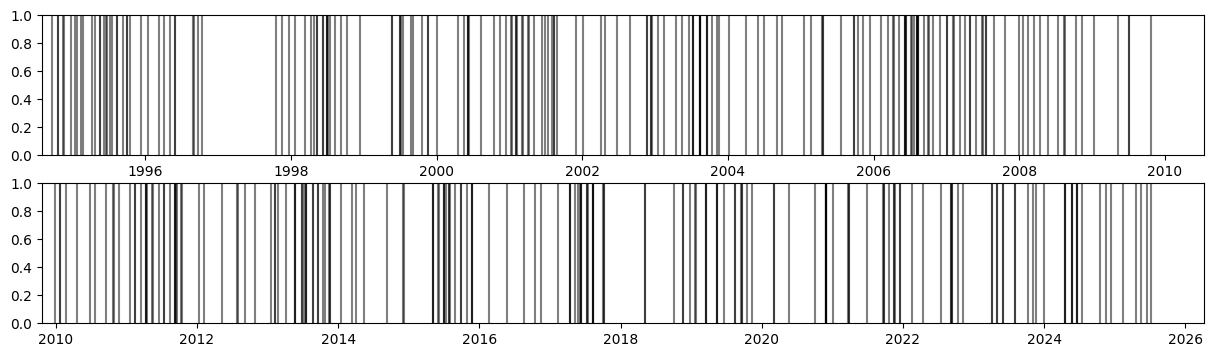

In [12]:
fig,axs = plt.subplots(ncols=1, nrows=2, figsize=(15, 4))

plt.subplot(211)
for i in np.arange((len(pcs)+1)/2, len(pcs)):
    plt.axvline(pcs['Date'].iloc[int(i)], c='k',ls='-', alpha=0.5)

plt.subplot(212)
for i in np.arange(0,len(pcs)/2):
    plt.axvline(pcs['Date'].iloc[int(i)], c='k',ls='-', alpha=0.5)


In [13]:
int(np.round(len(pcs)/3))

132

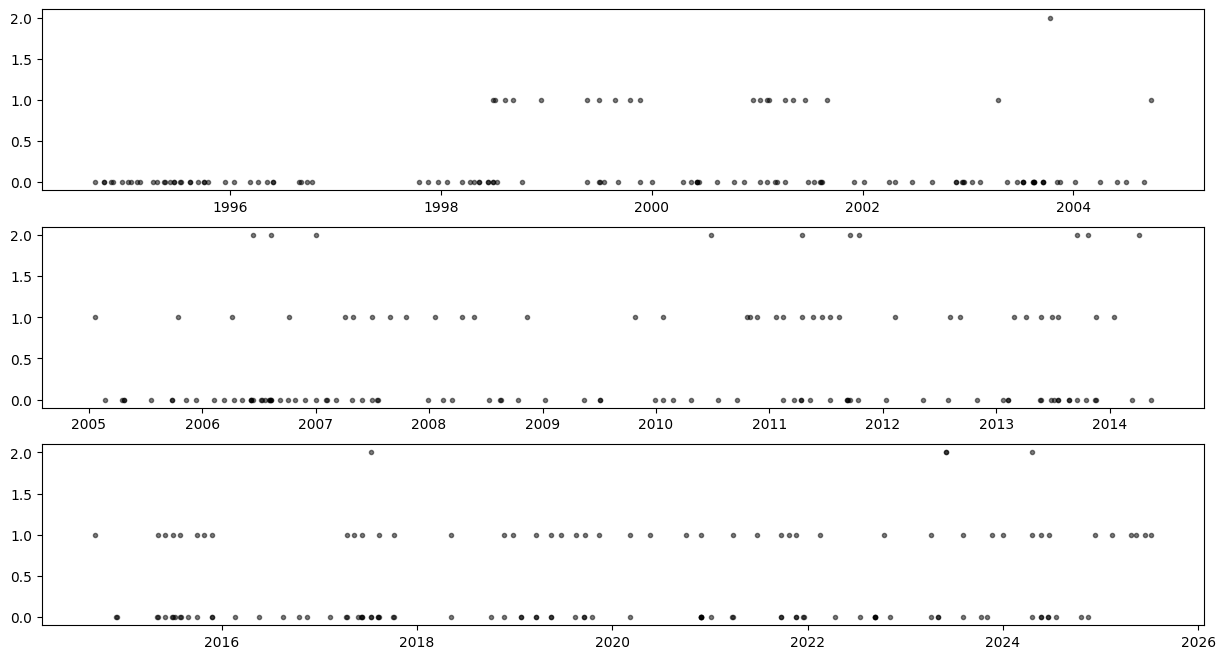

In [14]:
fig,axs = plt.subplots(ncols=1, nrows=3, figsize=(15, 8))

len_third = int(np.round(len(pcs)/3))

plt.subplot(311)
plt.scatter(pcs['Date'].iloc[len_third*2:], pcs['Highlighted'].iloc[len_third*2:], c='k',marker='.', alpha=0.5)

plt.subplot(312)
plt.scatter(pcs['Date'].iloc[len_third:len_third*2], pcs['Highlighted'].iloc[len_third:len_third*2], c='k',marker='.', alpha=0.5)

plt.subplot(313)
plt.scatter(pcs['Date'].iloc[0:len_third], pcs['Highlighted'].iloc[0:len_third], c='k',marker='.', alpha=0.5)
plt.show()

# Highlight key:
# 0 = no highlight
# 1 = yellow highlight
# 2 = orange highlight